# Assignment
# Text Generation using Vanilla RNN, LSTM and GRU

### Objective
Design and implement deep learning models capable of learning text patterns,
grammar and contextual dependencies to generate meaningful text.

Models Used:
1. Vanilla RNN
2. LSTM
3. GRU

We will compare:
- Training Loss
- Learning Behaviour
- Generated Text Quality

In [10]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import GRU
from tensorflow.keras.layers import Dense

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [11]:
corpus = """
elephants are the largest land animals on earth and are known for their intelligence and remarkable memory.
they belong to the family elephantidae and are found primarily in africa and asia.
african elephants are generally larger than asian elephants and have bigger ears.
elephants use their trunks for breathing smelling touching grasping and producing sound.
their trunks contain thousands of muscles that allow them to perform delicate and powerful movements.
an elephant can pick up a small object like a leaf or lift heavy tree branches with ease.
elephants are highly social animals and usually live in groups called herds.
a herd is often led by the oldest and most experienced female known as the matriarch.
young elephants learn important survival skills by observing older members of the herd.
communication among elephants occurs through vocal sounds body language and vibrations in the ground.
they can detect low frequency sounds over long distances and use them to stay connected.
elephants often show empathy cooperation and strong emotional bonds with one another.
researchers have observed elephants helping injured herd members and comforting distressed companions.
their memory helps them remember migration routes water sources and safe locations during droughts.
elephants can travel many kilometers in search of food and fresh water.
their diet mainly consists of grass leaves bark fruits roots and various types of vegetation.
an adult elephant can consume hundreds of kilograms of food in a single day.
because of their large size elephants require significant amounts of energy and water.
they play an important role in maintaining the balance of ecosystems.
by knocking down trees and dispersing seeds they help shape the landscape around them.
many plant species depend on elephants to spread their seeds across large distances.
for this reason elephants are often called ecosystem engineers.
elephants enjoy bathing in rivers lakes and mud pools to keep their bodies cool.
mud also protects their skin from insects and harsh sunlight.
calves stay close to their mothers and depend on them for protection and nourishment.
the bond between a mother elephant and her calf is extremely strong.
elephants have long lifespans and can live for several decades in the wild.
scientists continue to study elephant behavior to better understand animal intelligence.
many experiments suggest that elephants possess problem solving abilities and self awareness.
some elephants have demonstrated the ability to recognize themselves in mirrors.
their cognitive abilities are considered among the most advanced in the animal kingdom.
throughout history elephants have played important roles in human societies.
they have been used for transportation agriculture ceremonies and cultural events.
many ancient civilizations respected elephants for their strength wisdom and loyalty.
however elephant populations face numerous threats in the modern world.
habitat destruction reduces the space available for elephants to roam freely.
expanding human settlements often lead to conflicts between people and wildlife.
poaching for ivory remains one of the greatest dangers faced by elephants.
illegal hunting has caused significant declines in elephant populations in some regions.
governments and conservation organizations work together to protect elephants from these threats.
wildlife reserves and national parks provide safe habitats for many elephant populations.
educational programs help raise awareness about elephant conservation and environmental protection.
modern technology such as satellite tracking allows researchers to monitor elephant movements.
understanding migration patterns helps conservationists create better protection strategies.
many communities are becoming involved in efforts to preserve elephant habitats.
sustainable conservation requires cooperation between governments scientists and local populations.
future generations should have the opportunity to observe elephants in their natural environments.
protecting elephants also helps preserve biodiversity and ecological stability.
these magnificent animals continue to inspire researchers conservationists and nature lovers around the world.
their intelligence social behavior and importance to ecosystems make them one of the most fascinating species on earth.
"""

print(corpus)


elephants are the largest land animals on earth and are known for their intelligence and remarkable memory.
they belong to the family elephantidae and are found primarily in africa and asia.
african elephants are generally larger than asian elephants and have bigger ears.
elephants use their trunks for breathing smelling touching grasping and producing sound.
their trunks contain thousands of muscles that allow them to perform delicate and powerful movements.
an elephant can pick up a small object like a leaf or lift heavy tree branches with ease.
elephants are highly social animals and usually live in groups called herds.
a herd is often led by the oldest and most experienced female known as the matriarch.
young elephants learn important survival skills by observing older members of the herd.
communication among elephants occurs through vocal sounds body language and vibrations in the ground.
they can detect low frequency sounds over long distances and use them to stay connected.
ele

# Tokenization and Sequence Creation

Convert words into integers and create n-gram sequences.

In [12]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

input_sequences = []

for line in corpus.split("\n"):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

input_sequences = np.array(input_sequences)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("Input Shape:", X.shape)
print("Output Shape:", y.shape)

Vocabulary Size: 353
Input Shape: (576, 17)
Output Shape: (576,)


# Vanilla RNN Model

In [13]:
rnn_model = Sequential([

    Embedding(
        input_dim=total_words,
        output_dim=64,
        input_length=max_len-1
    ),

    SimpleRNN(128),

    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("RNN Training Completed")

Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.0417 - loss: 5.8310
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0608 - loss: 5.5352
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0573 - loss: 5.4709
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0608 - loss: 5.3528
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0625 - loss: 5.3216
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0642 - loss: 5.2558
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0712 - loss: 5.1685
Epoch 8/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0729 - loss: 5.0799
Epoch 9/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0851 - loss: 4.9557
Epoch 10/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1024 - loss: 4.8128
Epoch 11/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1250 - loss: 4.6460
Epoch 12/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy:

# LSTM Model

In [14]:
lstm_model = Sequential([

    Embedding(
        input_dim=total_words,
        output_dim=64,
        input_length=max_len-1
    ),

    LSTM(128),

    Dense(total_words, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("LSTM Training Completed")

Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.0521 - loss: 5.8554
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0608 - loss: 5.6338
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.0608 - loss: 5.4313
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0608 - loss: 5.3762
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.0608 - loss: 5.3338
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0642 - loss: 5.2774
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0764 - loss: 5.2158
Epoch 8/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0694 - loss: 5.1471
Epoch 9/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0712 - loss: 5.0778
Epoch 10/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.0729 - loss: 4.9986
Epoch 11/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0747 - loss: 4.9372
Epoch 12/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

# GRU Model

In [15]:
gru_model = Sequential([

    Embedding(
        input_dim=total_words,
        output_dim=64,
        input_length=max_len-1
    ),

    GRU(128),

    Dense(total_words, activation='softmax')
])

gru_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

gru_history = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("GRU Training Completed")

Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.0347 - loss: 5.8619
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0608 - loss: 5.7531
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0608 - loss: 5.4702
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0608 - loss: 5.3884
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0608 - loss: 5.3525
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.0590 - loss: 5.3024
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.0729 - loss: 5.2216
Epoch 8/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0729 - loss: 5.1032
Epoch 9/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0799 - loss: 4.9835
Epoch 10/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.0851 - loss: 4.8813
Epoch 11/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0990 - loss: 4.7358
Epoch 12/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step

# Training Loss Comparison

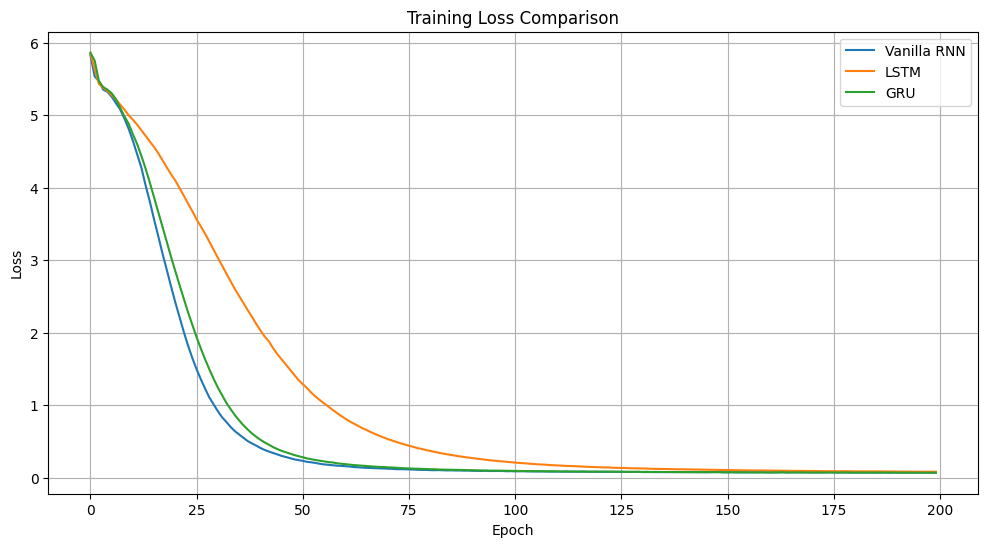

In [16]:
plt.figure(figsize=(12,6))

plt.plot(
    rnn_history.history['loss'],
    label='Vanilla RNN'
)

plt.plot(
    lstm_history.history['loss'],
    label='LSTM'
)

plt.plot(
    gru_history.history['loss'],
    label='GRU'
)

plt.title("Training Loss Comparison")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

# Text Generation Function

Uses np.argmax() for next-word prediction.

In [17]:
def generate_text(model, seed_text, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [seed_text]
        )[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

# Generate Text Samples

In [19]:
seed = "their"

print("="*70)

print("RNN Generated Text:")
print(generate_text(rnn_model, seed, 10))

print("\n")

print("LSTM Generated Text:")
print(generate_text(lstm_model, seed, 10))

print("\n")

print("GRU Generated Text:")
print(generate_text(gru_model, seed, 10))

print("="*70)

RNN Generated Text:
their memory helps them remember migration routes water sources and safe


LSTM Generated Text:
their diet mainly consists of grass leaves bark fruits roots and


GRU Generated Text:
their trunks contain thousands of muscles that allow them to perform


# Conclusion

- Vanilla RNN learns basic sequence patterns.
- LSTM captures long-term dependencies better.
- GRU trains faster while maintaining strong performance.
- Loss curves demonstrate learning behaviour of all three architectures.